In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt

**NOTATION**

*False* means *cloudy*

*True* means *clear*

**PROBABILITIES**

Probability that tomorrow will be *** given that today is ***

- clear given cloudy = 0.5
- cloudy given cloudy = 0.5
- cloudy given clear = 0.1
- clear given clear = 0.9

In [2]:
today = False #cloudy at the beginning
N_days = 10000 #number of following days
tomorrow = np.zeros(N_days, dtype="bool") #to store the forecast for the following day, the Markov Chain

In [3]:
#building the chain
for i in range(N_days):
    p = random.uniform(0, 1)
    
    if not today: #satisfied when "not today" = True, so when today = False (cloudy)
        if p <= 0.5:
            tomorrow[i] = False
        if p > 0.5:
            tomorrow[i] = True
            
    if today: #satisfied when today is True (clear)
        if p <= 0.1:
            tomorrow[i] = False
        if p > 0.1: #which would be 0.9 probability
            tomorrow[i] = True
    
    today = tomorrow[i]

In [4]:
#clear days over the whole period
print("percentage of clear days:", np.sum(tomorrow)/N_days) #in the sum, clear gives +1, while cloudy is +0
print("theoretical value:       ", 0.83)

percentage of clear days: 0.8307
theoretical value:        0.83


In [5]:
#cloudy days over the whole period
print("percentage of cloudy days:", len(tomorrow[tomorrow==False])/N_days) #selecting only the cloudy (False) ones: the length gives their amount
print("theoretical value         ", 0.17)

percentage of cloudy days: 0.1693
theoretical value          0.17


In [6]:
days = np.arange(1, N_days+1, 1) #steps in the Markov chain
clear_days = np.cumsum(tomorrow)/days #relative amount of clear days... which is the probability of a clear day

Text(0.5, 1.0, 'trace plot')

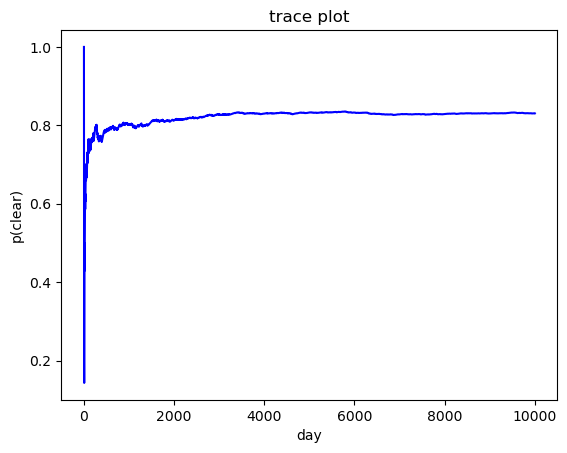

In [7]:
plt.plot(days, clear_days, "b")
plt.xlabel("day")
plt.ylabel("p(clear)")
plt.title("trace plot")

Text(0.5, 1.0, 'distribution')

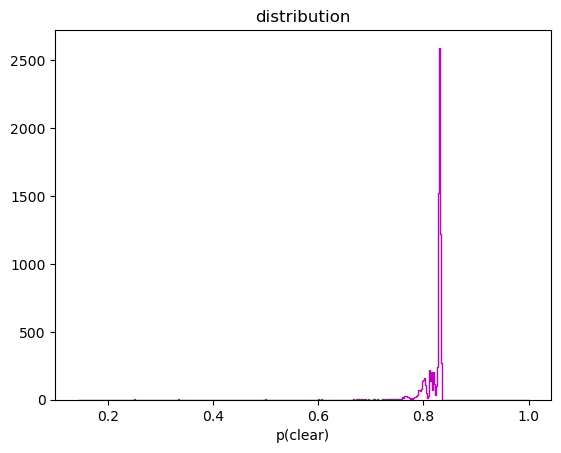

In [8]:
plt.hist(clear_days, bins=500, color="m", histtype="step")
plt.xlabel("p(clear)")
plt.title("distribution")

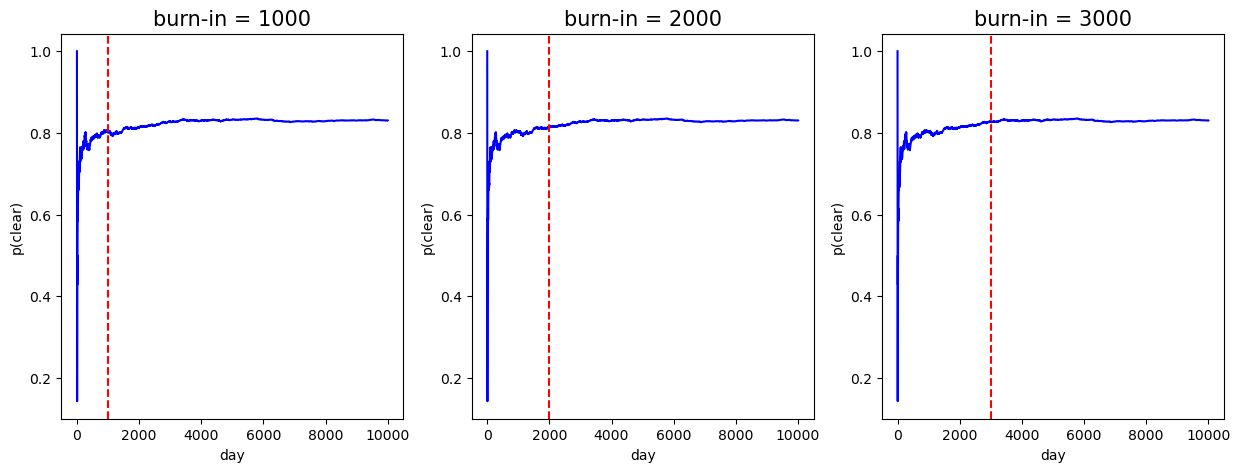

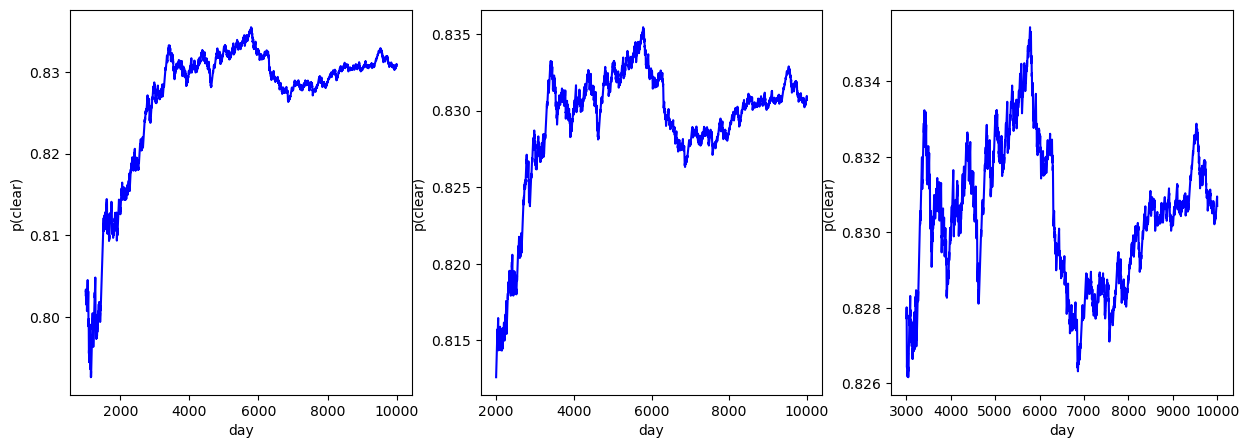

In [9]:
#trying different burn-ins
burn_ins = np.array([1000, 2000, 3000])
pos_plot = [131, 132, 133]

fig = plt.figure(figsize=((15, 5)))

for i in range(len(burn_ins)):
    axs = fig.add_subplot(pos_plot[i])
    axs.plot(days, clear_days, "b")
    axs.axvline(burn_ins[i], ls="--", color="r", label="burn-in")
    axs.set_xlabel("day", size=10)
    axs.set_ylabel("p(clear)", size=10)
    axs.set_title("burn-in = "+str(burn_ins[i]), size=15)

figzoom = plt.figure(figsize=((15, 5)))

for j in range(len(burn_ins)):
    axs = figzoom.add_subplot(pos_plot[j])
    axs.plot(days[burn_ins[j]:], clear_days[burn_ins[j]:], "b")
    axs.set_xlabel("day", size=10)
    axs.set_ylabel("p(clear)", size=10)

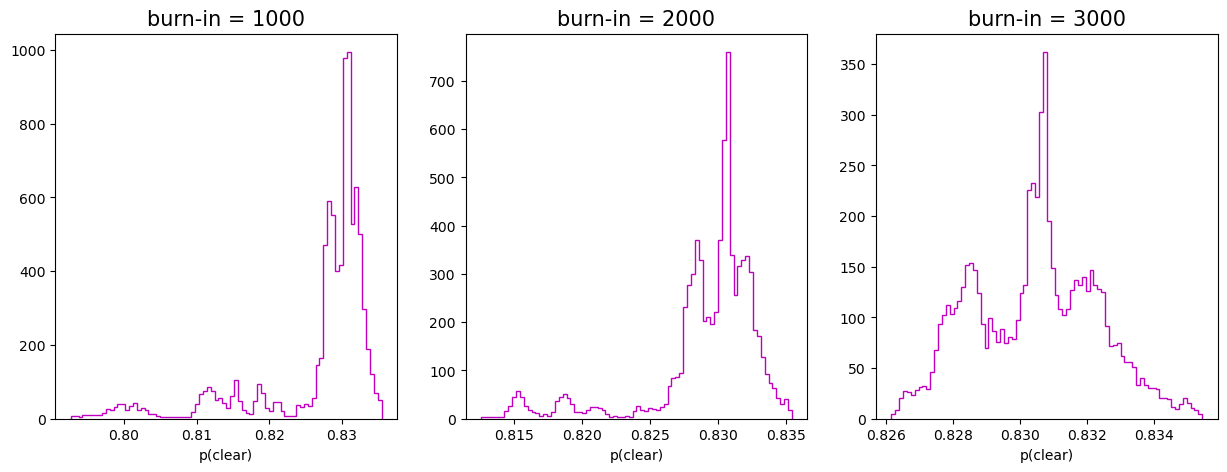

In [10]:
fig = plt.figure(figsize=((15, 5)))

for i in range(len(burn_ins)):
    axs = fig.add_subplot(pos_plot[i])
    axs.hist(clear_days[burn_ins[i]:], bins=80, color="m", histtype="step")
    axs.set_xlabel("p(clear)", size=10)
    axs.set_title("burn-in = "+str(burn_ins[i]), size=15)

the last one has lesser outliers and the trace plot has a smaller amplitude

In [11]:
#choosing
burn_in = 3000
median = np.median(clear_days[burn_in:])
percentiles = [np.percentile(clear_days[burn_in:], 16), np.percentile(clear_days[burn_in:], 84)]
print("median:", median)
print("percentiles:", percentiles)

median: 0.8305789932241792
percentiles: [0.8283760552946793, 0.8323251621033803]


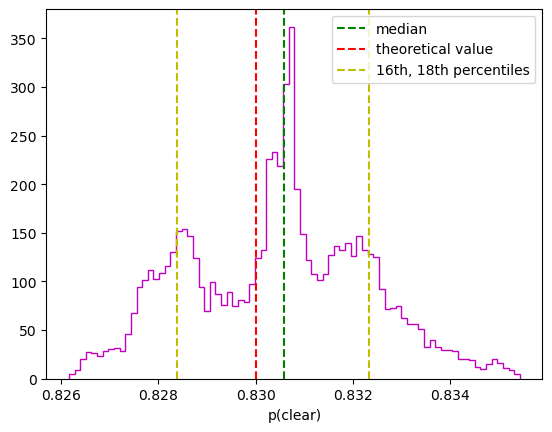

In [12]:
plt.hist(clear_days[burn_in:], bins=80, color="m", histtype="step")
plt.axvline(median, ls="--", color="g", label="median")
plt.axvline(0.83, ls="--", color="r", label="theoretical value")
plt.axvline(percentiles[0], ls="--", color="y", label="16th, 18th percentiles")
plt.axvline(percentiles[1], ls="--", color="y")
plt.xlabel("p(clear)")
plt.legend()